# Introduction
This project focuses on analyzing passenger choice between different types of airlines, specifically full-service and low-cost carriers. The objective is to understand how factors such as travel purpose, trip duration, destination, and passenger demographics influence airline selection.

Various machine learning models, including Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine (SVM), are applied to predict airline choice and evaluate model performance. The findings help explain passenger behavior and provide insights for airlines to improve service strategies and competitiveness.

# Problem Statement

The objective of this study is to model and explain passengers’ airline choice behavior using machine learning classification techniques. The analysis focuses on identifying the key factors such as age, destination, travel duration, and trip purpose that influence airline selection. The goal is to understand passenger preferences and decision-making patterns rather than only improving prediction accuracy.

This study emphasizes descriptive modeling to provide interpretable insights into passenger behavior.

# Data Description 
The dataset consists of passenger survey data related to airport and airline choice. It includes demographic variables such as age, gender, and income; travel characteristics such as trip purpose, trip duration, and number of trips; and service-related attributes such as destination, departure time, and access time.

Data cleaning involved removing columns with more than 30% missing values, dropping irrelevant features, and handling categorical variables through encoding. The final dataset was used for exploratory analysis and model building.

# Airline-Specific Variables

Airline → Selected airline (target variable)

FlyingCompanion → Number of people traveling together

SeatClass → Economy / Business / First class

Occupation → Passenger’s job category

# Common Variables
Common Variables (Both Models)

Destination → Where the passenger is traveling

TripDuration → Total length of the trip

DepartureTime / Hr / Mn → Time of flight departure

Income → Passenger’s income level

Age → Passenger’s age group

TripPurpose → Reason for travel (business, leisure, etc.)

NoTripsLastYear → Travel frequency

# Load data and basic cleaning

In [3]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_excel("airport_choice_survey_EN_ver2.0_Capstone.xlsx")

print("Original shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Original shape: (488, 28)

Columns:
 ['ID', 'Airport', 'Airline', 'Age', 'Gender', 'Nationality', 'TripPurpose', 'TripDuration', 'FlyingCompanion', 'ProvinceResidence', 'GroupTravel', 'NoTripsLastYear', 'FrequentFlightDestination', 'Destination', 'FlightNo', 'DepartureHr', 'DepartureMn', 'DepartureTime', 'SeatClass', 'Airfare', 'NoTransport', 'ModeTransport', 'AccessCost', 'AccessTime', 'Occupation', 'Income', 'MileageAirline', 'Mileage']


In [5]:
# Missing value summary
missing_summary = pd.DataFrame({
    "MissingCount": df.isna().sum(),
    "MissingPercent": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("MissingPercent", ascending=False)

print("\nMissing value summary:")
print(missing_summary)

# Drop columns with more than 30% missing
cols_to_drop_missing = missing_summary[missing_summary["MissingPercent"] > 30].index.tolist()

print("\nColumns with >30% missing:")
print(cols_to_drop_missing)

df_clean = df.drop(columns=cols_to_drop_missing)


Missing value summary:
                           MissingCount  MissingPercent
Mileage                             398           81.56
MileageAirline                      237           48.57
AccessCost                          197           40.37
Airfare                             155           31.76
FlightNo                            142           29.10
Income                              132           27.05
DepartureMn                         120           24.59
AccessTime                           97           19.88
DepartureHr                          33            6.76
Airline                              10            2.05
Destination                           5            1.02
SeatClass                             4            0.82
Gender                                3            0.61
Age                                   1            0.20
Occupation                            0            0.00
ModeTransport                         0            0.00
NoTransport             

Airfare was excluded due to high missing values, which may limit the ability to capture price sensitivity in airline choice.

In [7]:
# Remove ProvinceResidence
if "ProvinceResidence" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ProvinceResidence"])

# Remove ID
if "ID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["ID"])

print("\nNew shape after cleaning:", df_clean.shape)
print("\nRemaining columns:\n", df_clean.columns.tolist())


New shape after cleaning: (488, 22)

Remaining columns:
 ['Airport', 'Airline', 'Age', 'Gender', 'Nationality', 'TripPurpose', 'TripDuration', 'FlyingCompanion', 'GroupTravel', 'NoTripsLastYear', 'FrequentFlightDestination', 'Destination', 'FlightNo', 'DepartureHr', 'DepartureMn', 'DepartureTime', 'SeatClass', 'NoTransport', 'ModeTransport', 'AccessTime', 'Occupation', 'Income']


# Create Airline Target (Binary) + Categorical Analysis

In [13]:
# Drop rows where Airline is missing
df_airline = df_clean.dropna(subset=["Airline"]).copy()

print("Shape after removing missing airline:", df_airline.shape)

# Create binary target
# 1 = Full-service (1,2)
# 0 = Low-cost / Foreign (3,4)
df_airline["Airline_Binary"] = df_airline["Airline"].apply(
    lambda x: 1 if x in [1, 2, 1.0, 2.0] else 0
)

# Check distribution
print("\nAirline Binary Distribution:")
print(df_airline["Airline_Binary"].value_counts(normalize=True))

Shape after removing missing airline: (478, 22)

Airline Binary Distribution:
Airline_Binary
1    0.543933
0    0.456067
Name: proportion, dtype: float64


In [15]:
# Categorical Analysis
categorical_cols = [
    "Gender", "Nationality", "TripPurpose", "FlyingCompanion",
    "GroupTravel", "FrequentFlightDestination",
    "Destination", "SeatClass", "NoTransport",
    "ModeTransport", "Occupation"
]

print("\nCategorical Distribution:\n")

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_airline[col].value_counts(normalize=True))


Categorical Distribution:


Gender:
Gender
2.0    0.526316
1.0    0.473684
Name: proportion, dtype: float64

Nationality:
Nationality
1    0.774059
3    0.085774
2    0.066946
4    0.043933
5    0.029289
Name: proportion, dtype: float64

TripPurpose:
TripPurpose
1    0.665272
2    0.219665
4    0.060669
3    0.054393
Name: proportion, dtype: float64

FlyingCompanion:
FlyingCompanion
1     0.282427
2     0.263598
0     0.154812
3     0.083682
4     0.077406
5     0.023013
7     0.023013
6     0.018828
13    0.012552
10    0.012552
14    0.010460
8     0.008368
9     0.006276
20    0.006276
26    0.004184
12    0.004184
11    0.004184
34    0.002092
28    0.002092
Name: proportion, dtype: float64

GroupTravel:
GroupTravel
2    0.83682
1    0.16318
Name: proportion, dtype: float64

FrequentFlightDestination:
FrequentFlightDestination
1            0.320084
3            0.232218
2            0.213389
6            0.062762
5            0.054393
4            0.025105
7            0.025105
2,

The dataset shows a balanced distribution between full-service and low-cost/foreign airline choices. Most passengers travel individually and in economy class, indicating price sensitivity. Trip purpose and destination appear to be major factors influencing airline selection, while passenger characteristics such as occupation and nationality also contribute to differences in behavior.

# Distribution of Airline Choice

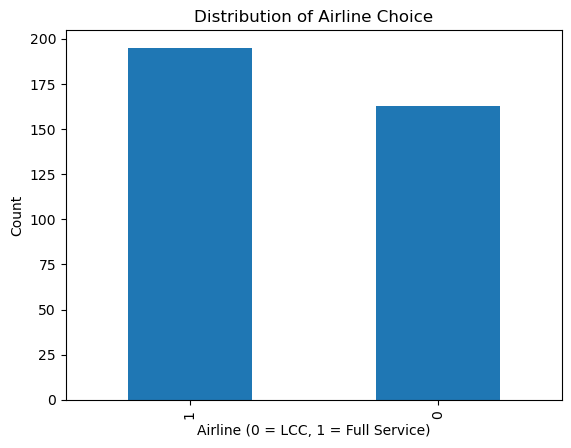

In [74]:
import matplotlib.pyplot as plt

y_train_airline.value_counts().plot(kind='bar')
plt.title("Distribution of Airline Choice")
plt.xlabel("Airline (0 = LCC, 1 = Full Service)")
plt.ylabel("Count")
plt.show()

The distribution shows how passengers are divided between different airline types. A relatively balanced distribution ensures that the model is not biased toward one class.

# Feature Selection + Dummy Variables

In [19]:
# Separate X and y
X_airline = df_airline.drop(columns=["Airline", "Airline_Binary"])
y_airline = df_airline["Airline_Binary"]

print("X shape:", X_airline.shape)
print("y shape:", y_airline.shape)


# Identify numeric and categorical columns
num_cols_airline = X_airline.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols_airline = X_airline.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:\n", num_cols_airline)
print("\nCategorical columns:\n", cat_cols_airline)


# Convert categorical to dummy variables
X_airline = pd.get_dummies(X_airline, columns=cat_cols_airline, drop_first=True)

print("\nAfter dummy encoding:")
print("New shape:", X_airline.shape)

X shape: (478, 21)
y shape: (478,)

Numeric columns:
 ['Airport', 'Age', 'Gender', 'Nationality', 'TripPurpose', 'TripDuration', 'FlyingCompanion', 'GroupTravel', 'NoTripsLastYear', 'Destination', 'DepartureMn', 'DepartureTime', 'SeatClass', 'NoTransport', 'ModeTransport', 'AccessTime', 'Occupation', 'Income']

Categorical columns:
 ['FrequentFlightDestination', 'FlightNo', 'DepartureHr']

After dummy encoding:
New shape: (478, 221)


# Train/Test Split + Logistic Regression

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Train-test split
X_train_airline, X_test_airline, y_train_airline, y_test_airline = train_test_split(
    X_airline,
    y_airline,
    test_size=0.25,
    random_state=42,
    stratify=y_airline
)

print("Train shape:", X_train_airline.shape)
print("Test shape:", X_test_airline.shape)

Train shape: (358, 221)
Test shape: (120, 221)


In [26]:
print("Missing values in X_train_airline:")
print(X_train_airline.isna().sum()[X_train_airline.isna().sum() > 0])

print("\nMissing values in X_test_airline:")
print(X_test_airline.isna().sum()[X_test_airline.isna().sum() > 0])

Missing values in X_train_airline:
Gender           3
Destination      2
DepartureMn     88
SeatClass        4
AccessTime      72
Income         100
dtype: int64

Missing values in X_test_airline:
DepartureMn    26
AccessTime     22
Income         27
dtype: int64


In [98]:
# Fill missing values using TRAINING data median

numeric_cols = ['Age', 'Income', 'AccessTime', 'TripDuration', 'DepartureMn']

for col in numeric_cols:
    median_val = X_train_airline[col].median()
    X_train_airline[col] = X_train_airline[col].fillna(median_val)
    X_test_airline[col] = X_test_airline[col].fillna(median_val)

print("Remaining missing in X_train_airline:", X_train_airline.isna().sum().sum())
print("Remaining missing in X_test_airline:", X_test_airline.isna().sum().sum())

Remaining missing in X_train_airline: 0
Remaining missing in X_test_airline: 0


In [100]:
# Logistic Regression
log_model_airline = LogisticRegression(max_iter=2000)

log_model_airline.fit(X_train_airline, y_train_airline)

y_pred_airline = log_model_airline.predict(X_test_airline)

print("\nLogistic Regression - Airline Model")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airline, y_pred_airline))

print("\nAccuracy:", accuracy_score(y_test_airline, y_pred_airline))
print("Precision:", precision_score(y_test_airline, y_pred_airline))
print("Recall:", recall_score(y_test_airline, y_pred_airline))
print("F1 Score:", f1_score(y_test_airline, y_pred_airline))


Logistic Regression - Airline Model

Confusion Matrix:
[[33 22]
 [18 47]]

Accuracy: 0.6666666666666666
Precision: 0.6811594202898551
Recall: 0.7230769230769231
F1 Score: 0.7014925373134329


Logistic regression shows moderate performance for airline choice prediction, with an accuracy of 66.7%. This suggests that airline choice behavior is more complex and may not be well captured by a simple linear model, indicating the need for more flexible models such as decision trees and ensemble methods.

# Decision Tree


Decision Tree (Big Tree) - Airline

Confusion Matrix:
[[36 19]
 [14 51]]

Accuracy: 0.725


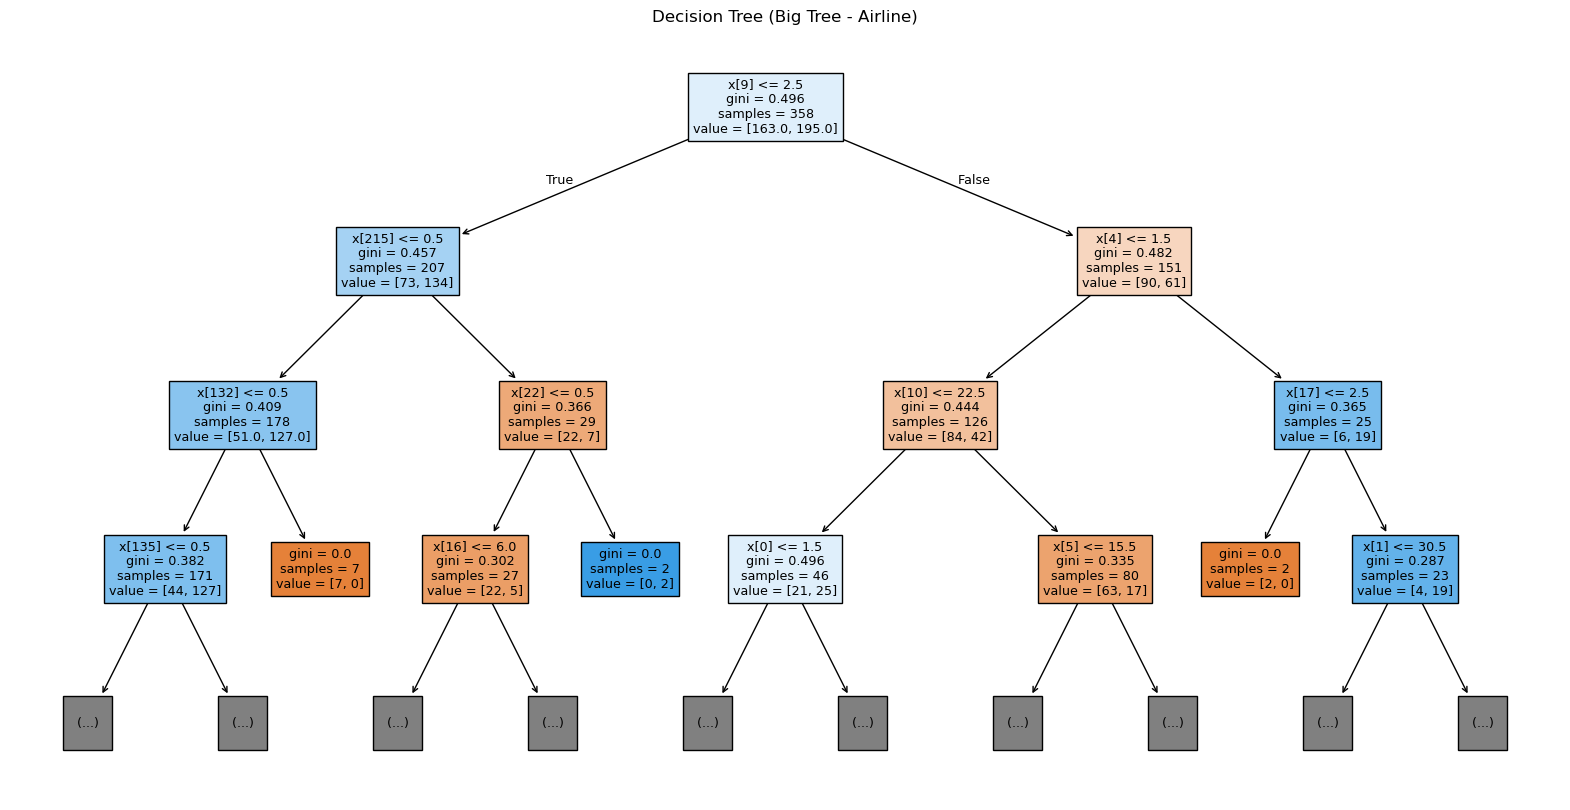

In [104]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# BIG TREE
tree_big_airline = DecisionTreeClassifier(random_state=42)

tree_big_airline.fit(X_train_airline, y_train_airline)

y_pred_tree_big_airline = tree_big_airline.predict(X_test_airline)

print("\nDecision Tree (Big Tree) - Airline")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airline, y_pred_tree_big_airline))

print("\nAccuracy:", accuracy_score(y_test_airline, y_pred_tree_big_airline))


# Plot big tree (partial view)
plt.figure(figsize=(20,10))
tree.plot_tree(tree_big_airline, filled=True, max_depth=3)
plt.title("Decision Tree (Big Tree - Airline)")
plt.show()

Airline choice is more complex and less predictable than airport choice.

# Small Tree


Decision Tree (Small Tree) - Airline

Confusion Matrix:
[[26 29]
 [ 9 56]]

Accuracy: 0.6833333333333333


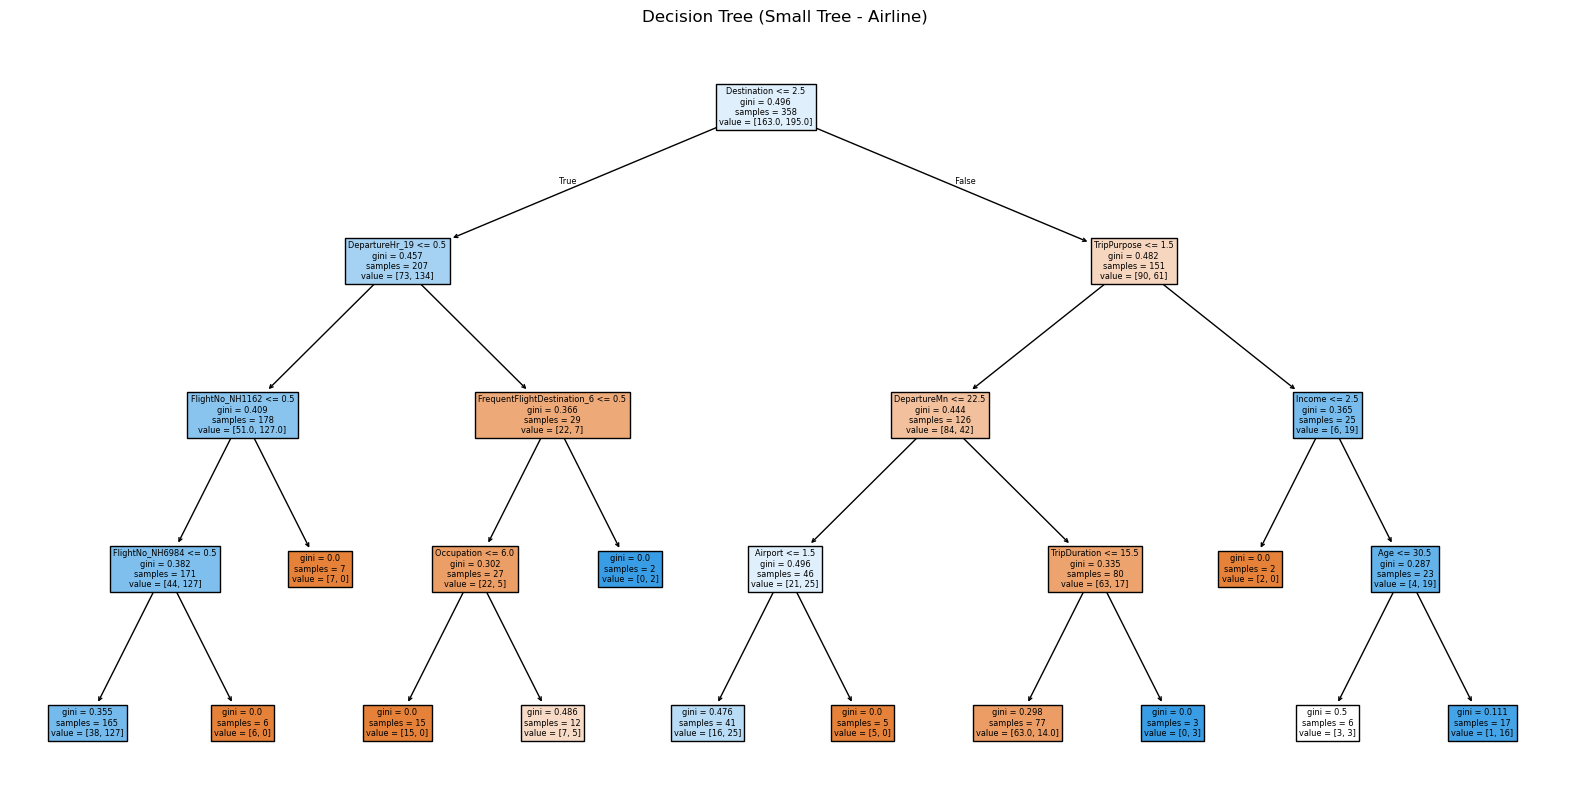

In [108]:
# SMALL TREE (Pruned)
tree_small_airline = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=20,
    random_state=42
)

tree_small_airline.fit(X_train_airline, y_train_airline)

y_pred_tree_small_airline = tree_small_airline.predict(X_test_airline)

print("\nDecision Tree (Small Tree) - Airline")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airline, y_pred_tree_small_airline))

print("\nAccuracy:", accuracy_score(y_test_airline, y_pred_tree_small_airline))


# Plot SMALL tree
plt.figure(figsize=(20,10))
tree.plot_tree(tree_small_airline, filled=True, feature_names=X_train_airline.columns)
plt.title("Decision Tree (Small Tree - Airline)")
plt.show()

The decision tree analysis shows that destination is the most influential factor in airline choice, followed by trip purpose and departure time. Passenger characteristics such as income and age also contribute to the decision. Compared to the fully grown tree, the simplified tree provides better interpretability while maintaining reasonable predictive performance.

Airline choice is more complex and influenced by multiple interacting factors.

# Random Forest

In [113]:
from sklearn.ensemble import RandomForestClassifier

rf_model_airline = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model_airline.fit(X_train_airline, y_train_airline)

y_pred_rf_airline = rf_model_airline.predict(X_test_airline)

print("\nRandom Forest - Airline Model")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_airline, y_pred_rf_airline))

print("\nAccuracy:", accuracy_score(y_test_airline, y_pred_rf_airline))
print("Precision:", precision_score(y_test_airline, y_pred_rf_airline))
print("Recall:", recall_score(y_test_airline, y_pred_rf_airline))
print("F1 Score:", f1_score(y_test_airline, y_pred_rf_airline))


Random Forest - Airline Model

Confusion Matrix:
[[29 26]
 [ 6 59]]

Accuracy: 0.7333333333333333
Precision: 0.6941176470588235
Recall: 0.9076923076923077
F1 Score: 0.7866666666666666


Random Forest achieved the best performance among airline models with an accuracy of 73.3%. The model shows high recall (91%), indicating strong ability to identify full-service airline choices. However, the lower precision suggests some difficulty in distinguishing between airline categories. Compared to airport choice, airline choice appears more complex and less predictable.

Airline choice is significantly more complex and harder to predict than airport choice.

## Random Forest performed best among the models, especially in terms of recall, suggesting it effectively captures passenger preferences between full-service and low-cost airlines.

# Airline Choice vs Destination

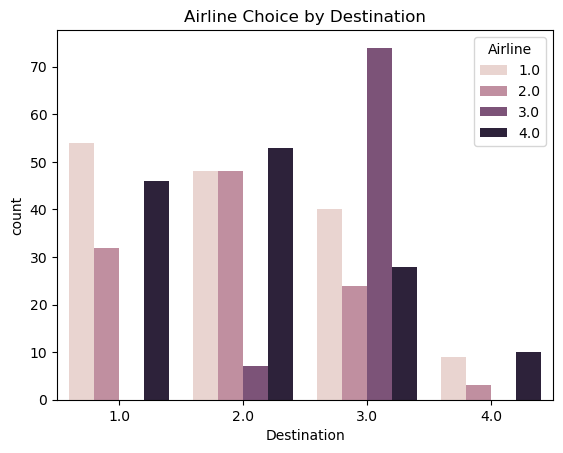

In [119]:
import seaborn as sns

sns.countplot(x='Destination', hue='Airline', data=df_airline)
plt.title("Airline Choice by Destination")
plt.show()

The plot shows that airline choice varies across destinations, indicating that route characteristics play a significant role in airline selection.

# Airline Choice vs Trip Purpose

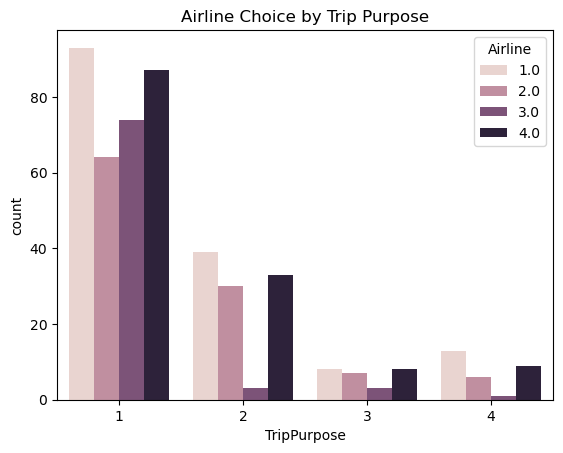

In [123]:
sns.countplot(x='TripPurpose', hue='Airline', data=df_airline)
plt.title("Airline Choice by Trip Purpose")
plt.show()

The results indicate that business and leisure travelers exhibit different airline preferences, suggesting behavioral differences across trip purposes.

# Airline Choice vs Age

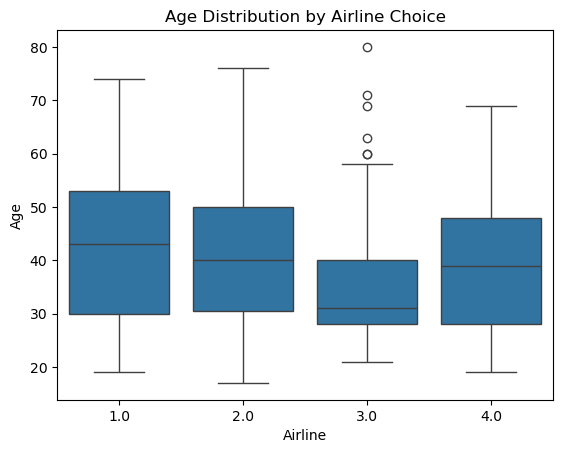

In [127]:
sns.boxplot(x='Airline', y='Age', data=df_airline)
plt.title("Age Distribution by Airline Choice")
plt.show()

Age differences across airline choices suggest that different age groups prefer different types of airlines.

These visualizations complement the model results by providing intuitive insights into passenger behavior.

# Feature Importance


Top 10 Important Features (Airline):
Age                0.060010
Destination        0.057891
DepartureMn        0.055426
TripDuration       0.054987
FlyingCompanion    0.045159
TripPurpose        0.040803
NoTripsLastYear    0.039250
AccessTime         0.035611
ModeTransport      0.034506
Occupation         0.034408
dtype: float64


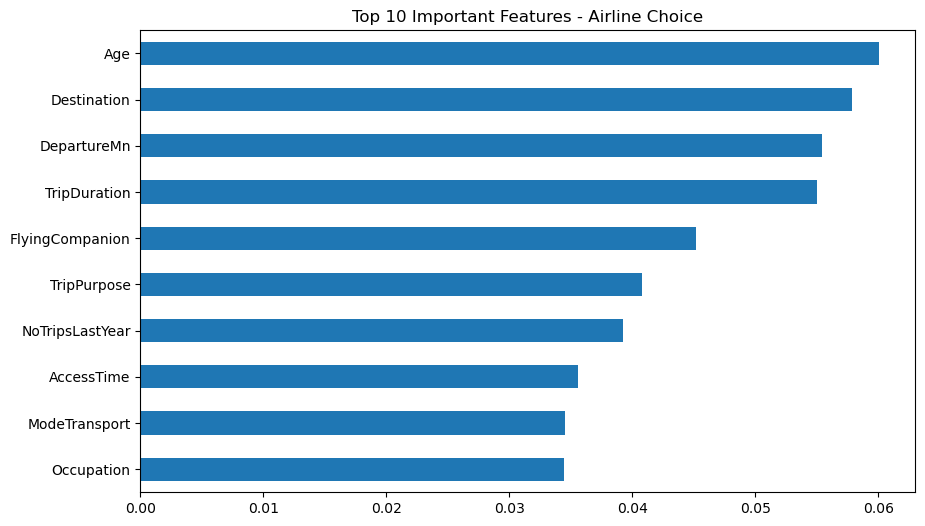

In [132]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
feature_importance_airline = pd.Series(
    rf_model_airline.feature_importances_,
    index=X_train_airline.columns
).sort_values(ascending=False)

top_features_airline = feature_importance_airline.head(10)

print("\nTop 10 Important Features (Airline):")
print(top_features_airline)

# Plot
plt.figure(figsize=(10,6))
top_features_airline.plot(kind='barh')
plt.title("Top 10 Important Features - Airline Choice")
plt.gca().invert_yaxis()
plt.show()

The feature importance analysis shows that airline choice is influenced by a combination of passenger characteristics and travel-related factors. Age emerges as the most important factor, indicating that different age groups have different airline preferences. Destination and travel time variables also play a significant role, while behavioral factors such as trip purpose and travel frequency further influence decisions. Compared to airport choice, airline choice appears more complex and less predictable.

# Conclusion

This study analyzed passengers’ airport and airline choice behavior using multiple modeling approaches. The results show that airport choice is primarily driven by destination and travel-related factors, and can be predicted with high accuracy. In contrast, airline choice is more complex and influenced by a combination of passenger characteristics, travel behavior, and service-related factors, resulting in lower predictive performance. Among the models, Random Forest performed best for both problems, while decision trees provided interpretable insights into decision-making behavior. These findings highlight the importance of both operational and demographic factors in shaping passenger travel decisions.

# POLICY IMPLICATIONS

The findings suggest that improving route availability and destination connectivity is crucial for influencing airport choice. For airline choice, targeting different passenger segments based on age, travel purpose, and frequency can be effective. Airlines should optimize schedules and provide tailored services to different customer groups, while airports and airlines should coordinate strategies to enhance overall passenger experience.